A more complex example
======================

Here, we are going to learn how to use *pyKasso* with a little more complex example than the [example_01_quick_introduction.ipynb](example_01_quick_introduction.ipynb).

This example is intended to show more specifics functionalities and to understand how python loops can be used to perform several simulations.

Here, we are going to use the datafiles from the Betteraz's catchment.

Create a new project
--------------------

First, we need to import the pyKasso module:

In [1]:
import pykasso as pk

Betteraz's datafiles are already integrated in the *pyKasso* module. <br>
With the ``get_settings()`` function, the module create a copy of the default settings file on the directory where the script is executed. <br>
If the ``example`` argument is ``betteraz``, the function will provide us all the settings file from the Betteraz's catchment.  

In [2]:
pk.get_settings(example='betteraz')

The function created a directory named ``inputs``. Inside, we can find all the settings files required to reproduce the Betteraz's catchment. <br>

We can now create an instance of the ``SKS`` class and give the relative path of a settings file.

In [3]:
betteraz = pk.SKS('inputs/betteraz_case_1.yaml')

Rasterizing: 100%|███████████████████████████████████████████████████████████████| 3884/3884 [00:00<00:00, 7786.09it/s]


Visualize the generated environment
-------------------------------------
	
Let's have a look on the geological settings:

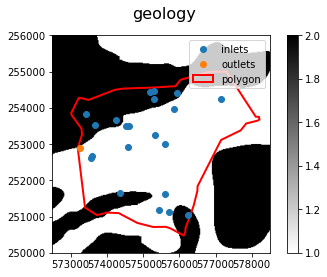

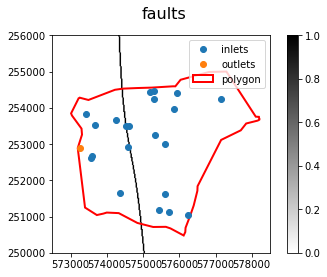

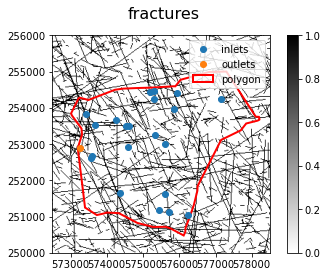

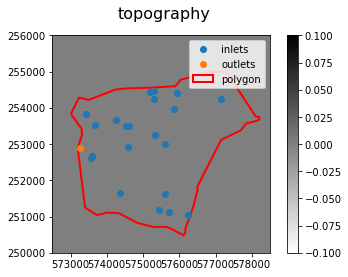

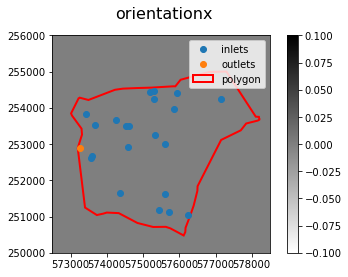

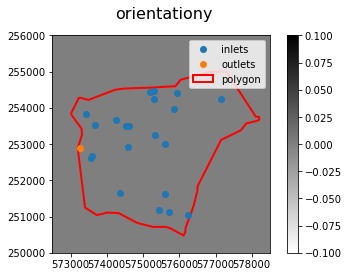

In [4]:
for data in ["geology", "faults", "fractures", "topography", "orientationx", "orientationy"]:
    betteraz.show_catchment(data=data)

Compute karst network and tweak parameters
------------------------------------------

We can simulate different karst network by changing some parameters. There is a ``get`` and a ``set`` method for almost each parameter.

Now, we can write a loop and change some parameters. For example, let's see the influence of the alpha parameter on the generated karstic networks:


 This network contains  1  connected components

Computing:
 - mean length,cv length,length entropy,mean tortuosity
 - orientation entropy,aspl,cpd,md,cv degree,cvd


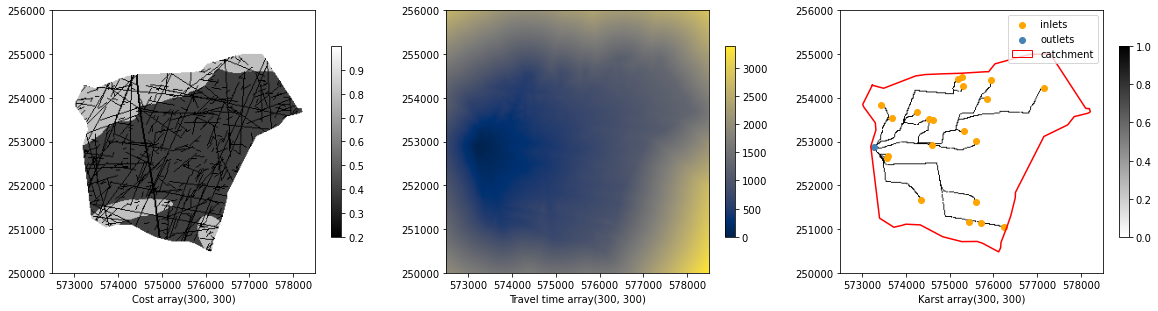

Rasterizing: 100%|███████████████████████████████████████████████████████████████| 3889/3889 [00:00<00:00, 6997.11it/s]



 This network contains  1  connected components

Computing:
 - mean length,cv length,length entropy,mean tortuosity
 - orientation entropy,aspl,cpd,md,cv degree,cvd


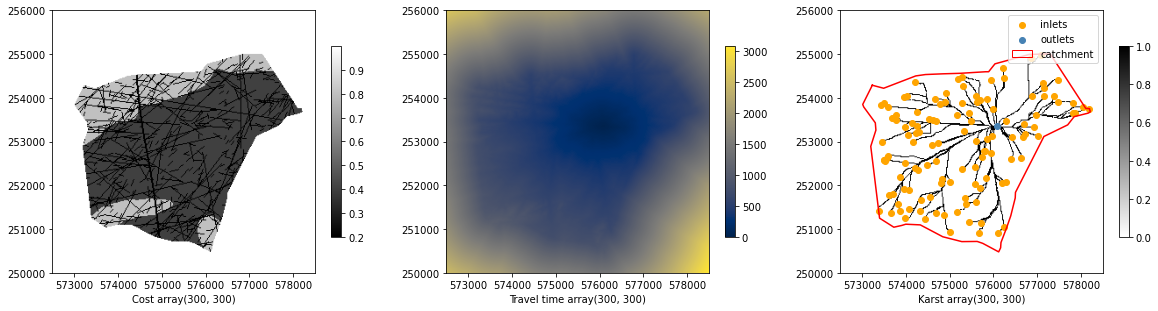

Rasterizing: 100%|███████████████████████████████████████████████████████████████| 3950/3950 [00:00<00:00, 7918.17it/s]



 This network contains  1  connected components

Computing:
 - mean length,cv length,length entropy,mean tortuosity
 - orientation entropy,aspl,cpd,md,cv degree,cvd


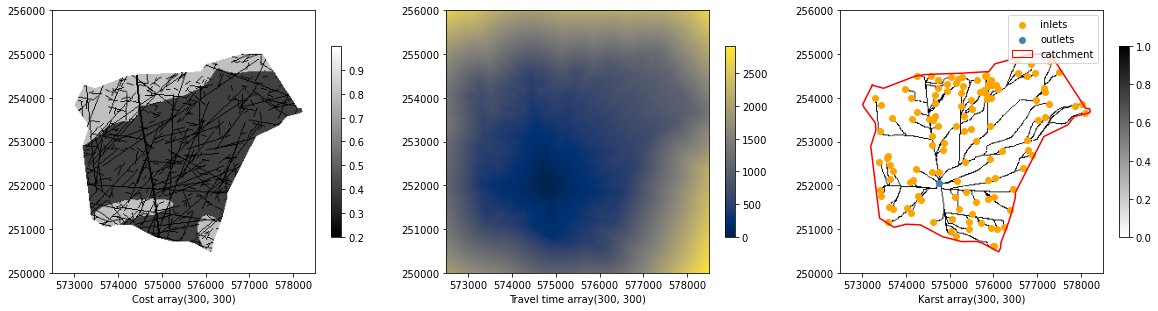

Rasterizing: 100%|███████████████████████████████████████████████████████████████| 3893/3893 [00:00<00:00, 6635.12it/s]



 This network contains  1  connected components

Computing:
 - mean length,cv length,length entropy,mean tortuosity
 - orientation entropy,aspl,cpd,md,cv degree,cvd


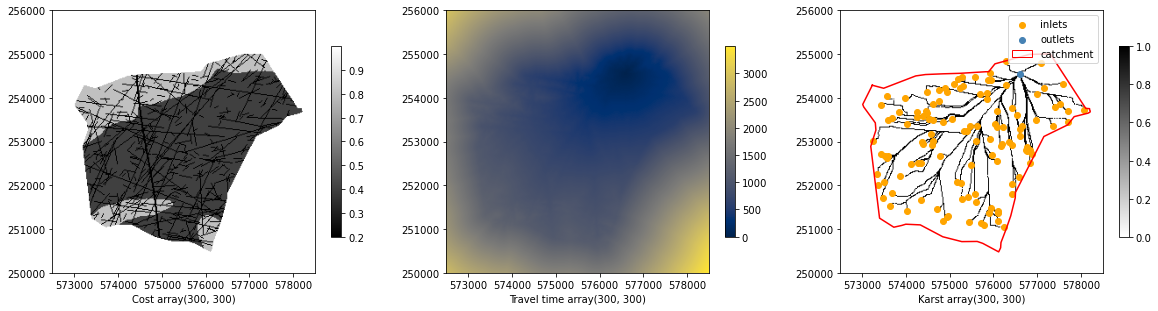

In [5]:
betteraz.compute_karst_network()
betteraz.show()

for i in range(3):
    betteraz.update_fractures()
    betteraz.set_outlets_mode('random')
    betteraz.set_outlets_number(1)
    betteraz.set_inlets_mode('composite')
    betteraz.set_inlets_number(100)
    betteraz.update_outlets()
    betteraz.update_inlets()
    betteraz.compute_karst_network()
    betteraz.show()

In [6]:
betteraz.karst_simulations

In [7]:
betteraz.karst_simulations[0].__dict__.keys()

dict_keys(['maps', 'points', 'network', 'stats', 'settings'])

In [8]:
#betteraz.compare_stats()